In [12]:
# ==========================
# STEP 1: Environment Setup & Imports (MobileNetV2)
# ==========================

# Core libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight

# Deep learning
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.optimizers import RMSprop  # Updated optimizer

# Image sharpening filter
from PIL import Image, ImageFilter
def sharpen_image(img):
    return img.filter(ImageFilter.SHARPEN)

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Display settings
plt.style.use("seaborn-v0_8-darkgrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 120)

# Test GPU availability
print("✅ All libraries imported successfully.")
print("TensorFlow version:", tf.__version__)
print("Num GPUs available:", len(tf.config.list_physical_devices('GPU')))


✅ All libraries imported successfully.
TensorFlow version: 2.14.0
Num GPUs available: 1


✅ Sharpened images folder found at: /mnt/k/I.T/PROJECTS/Skin Disease Detection/data/HAM10000_images_sharp
✅ Metadata file found at: /mnt/k/I.T/PROJECTS/Skin Disease Detection/data/HAM10000_metadata.csv
Metadata loaded successfully with shape: (10015, 7)
✅ Total valid images after filtering: 10015

Class distribution:
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


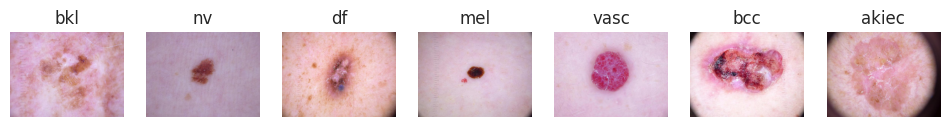

In [14]:
# ==========================
# STEP 2: Dataset Loading & Metadata Linking (Pre-sharpened)
# ==========================

from pathlib import Path
import numpy as np

# Paths (WSL-compatible)
BASE_DIR = Path("/mnt/k/I.T/PROJECTS/Skin Disease Detection/data")
SHARP_DIR = BASE_DIR / "HAM10000_images_sharp"  # Direct reference to sharpened images
METADATA_PATH = BASE_DIR / "HAM10000_metadata.csv"

# --- 1️⃣ Sanity checks ---
if not SHARP_DIR.exists():
    raise FileNotFoundError(f"Sharpened image directory not found: {SHARP_DIR}")
if not METADATA_PATH.exists():
    raise FileNotFoundError(f"Metadata CSV not found: {METADATA_PATH}")

print(f"✅ Sharpened images folder found at: {SHARP_DIR}")
print(f"✅ Metadata file found at: {METADATA_PATH}")

# --- 2️⃣ Load metadata ---
metadata = pd.read_csv(METADATA_PATH)
print(f"Metadata loaded successfully with shape: {metadata.shape}")

# --- 3️⃣ Add image paths & filter valid images ---
valid_extensions = ['.jpg', '.jpeg', '.png']
metadata['image_path'] = metadata['image_id'].apply(lambda x: SHARP_DIR / f"{x}.jpg")
metadata = metadata[metadata['image_path'].apply(lambda x: x.exists() and x.suffix.lower() in valid_extensions)].reset_index(drop=True)

print(f"✅ Total valid images after filtering: {len(metadata)}")

# --- 4️⃣ Quick class distribution ---
print("\nClass distribution:")
print(metadata['dx'].value_counts())

# --- 5️⃣ Visualize sample images ---
sample_df = metadata.groupby('dx').head(1)  # 1 sample per class
plt.figure(figsize=(12,6))
for i, row in enumerate(sample_df.itertuples(), 1):
    img = Image.open(row.image_path)
    plt.subplot(1, len(sample_df), i)
    plt.imshow(img)
    plt.title(row.dx)
    plt.axis('off')
plt.show()

In [15]:
# ==========================
# STEP 3: Train–Validation–Test Split
# ==========================

from sklearn.model_selection import GroupShuffleSplit

# --- 1️⃣ Define split ratios ---
train_ratio = 0.7
val_ratio = 0.15  # will split remaining 30% into val/test
test_ratio = 0.15

# --- 2️⃣ Use lesion_id as groups to avoid leakage ---
groups = metadata['lesion_id']

# --- 3️⃣ First split: Train and Temp (val + test) ---
gss = GroupShuffleSplit(n_splits=1, train_size=train_ratio, random_state=42)
train_idx, temp_idx = next(gss.split(metadata, groups=groups))

train_df = metadata.iloc[train_idx].reset_index(drop=True)
temp_df = metadata.iloc[temp_idx].reset_index(drop=True)

# --- 4️⃣ Second split: Temp into Validation and Test ---
temp_groups = temp_df['lesion_id']
val_size = val_ratio / (val_ratio + test_ratio)  # proportion within temp

gss_temp = GroupShuffleSplit(n_splits=1, train_size=val_size, random_state=42)
val_idx, test_idx = next(gss_temp.split(temp_df, groups=temp_groups))

val_df = temp_df.iloc[val_idx].reset_index(drop=True)
test_df = temp_df.iloc[test_idx].reset_index(drop=True)

# --- 5️⃣ Summary ---
print(f"✅ Train samples: {len(train_df)}")
print(f"✅ Validation samples: {len(val_df)}")
print(f"✅ Test samples: {len(test_df)}")

# Optional: visualize class distribution in splits
print("\nClass distribution in Train:")
print(train_df['dx'].value_counts())
print("\nClass distribution in Validation:")
print(val_df['dx'].value_counts())
print("\nClass distribution in Test:")
print(test_df['dx'].value_counts())


✅ Train samples: 7002
✅ Validation samples: 1519
✅ Test samples: 1494

Class distribution in Train:
dx
nv       4718
mel       770
bkl       741
bcc       381
akiec     207
vasc       96
df         89
Name: count, dtype: int64

Class distribution in Validation:
dx
nv       991
bkl      206
mel      156
bcc       65
akiec     57
vasc      25
df        19
Name: count, dtype: int64

Class distribution in Test:
dx
nv       996
mel      187
bkl      152
bcc       68
akiec     63
vasc      21
df         7
Name: count, dtype: int64


In [19]:
# ==========================
# STEP 4: Preprocessing & Augmentation (MobileNetV2) - Updated
# ==========================

from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Image size & batch size
# IMG_SIZE = (224, 224)
# BATCH_SIZE = 32

IMG_SIZE = (224, 224)  # Increased resolution
BATCH_SIZE = 24  # Slightly smaller to handle larger images


# ------------------------
# 1️⃣ Compute class weights for imbalance
# ------------------------
le = LabelEncoder()
train_labels_encoded = le.fit_transform(train_df['dx'])
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels_encoded),
    y=train_labels_encoded
)
class_weights_dict = dict(enumerate(class_weights))
print("✅ Class weights:", class_weights_dict)

# ------------------------
# 2️⃣ ImageDataGenerator setup (enhanced augmentation)
# ------------------------

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.12,
    height_shift_range=0.12,
    zoom_range=0.15,
    shear_range=0.08,
    brightness_range=[0.9,1.1],
    horizontal_flip=True,
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(
    rescale=1./255  # Normalize only
)


# Convert Path objects to strings
train_df['image_path'] = train_df['image_path'].astype(str)
val_df['image_path'] = val_df['image_path'].astype(str)
test_df['image_path'] = test_df['image_path'].astype(str)

# ------------------------
# 3️⃣ Flow from dataframe
# ------------------------
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='image_path',
    y_col='dx',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=42
)

val_generator = val_test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col='image_path',
    y_col='dx',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = val_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='image_path',
    y_col='dx',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)


✅ Class weights: {0: 4.832298136645963, 1: 2.625421822272216, 2: 1.3499132446500868, 3: 11.23916532905297, 4: 1.2990723562152133, 5: 0.21201477623690426, 6: 10.419642857142858}
Found 7002 validated image filenames belonging to 7 classes.
Found 1519 validated image filenames belonging to 7 classes.
Found 1494 validated image filenames belonging to 7 classes.


In [20]:
#==========================
#STEP 5: Model Building & Compilation (MobileNetV2) - Updated
#==========================

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# Number of classes
NUM_CLASSES = len(le.classes_)
print("Number of classes:", NUM_CLASSES)

# Load pretrained MobileNetV2 base (exclude top)
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)  # Match generator size
)
base_model.trainable = False  # freeze initially

# Build the model
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(512, activation='relu'),  # Increased width
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(256, activation='relu'),  # Additional layer
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

# Install tensorflow-addons first if not installed
!pip install tensorflow-addons
import tensorflow_addons as tfa

# Define callbacks here so they're available globally
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=8,
    restore_best_weights=True,
    verbose=1
)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=4,
    min_lr=1e-7,
    verbose=1
)
model_checkpoint = ModelCheckpoint(
    "best_mobilenetv2_model.h5",
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

# Compile with focal loss
model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss=tfa.losses.SigmoidFocalCrossEntropy(alpha=0.25, gamma=2.0),
    metrics=['accuracy', 
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')]
)

model.summary()

Number of classes: 7

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip
Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 mobilenetv2_1.00_224 (Func  (None, 7, 7, 1280)        2257984   
 tional)                                                         
                                                                 
 global_average_pooling2d_3  (None, 1280)              0         
  (GlobalAveragePooling2D)                                       
                                                                 
 batch_normalization_5 (Bat  (None, 1280)              5120      
 chNormalization)                                                
                                                                 
 dropout_7 (Dropout)         (None, 1280)              0         
                                                        

🚀 Starting initial training with frozen backbone...
Epoch 1/20
292/292 [==============================] - ETA: 0s - loss: 0.3010 - accuracy: 0.3779 - precision: 0.6221 - recall: 0.1390
Epoch 1: val_accuracy improved from -inf to 0.47202, saving model to best_mobilenetv2_model.h5
292/292 [==============================] - 108s 367ms/step - loss: 0.3010 - accuracy: 0.3779 - precision: 0.6221 - recall: 0.1390 - val_loss: 0.2689 - val_accuracy: 0.4720 - val_precision: 0.8388 - val_recall: 0.1679 - lr: 0.0010
Epoch 2/20
292/292 [==============================] - ETA: 0s - loss: 0.2894 - accuracy: 0.4187 - precision: 0.6840 - recall: 0.1574
Epoch 2: val_accuracy improved from 0.47202 to 0.47268, saving model to best_mobilenetv2_model.h5
292/292 [==============================] - 107s 367ms/step - loss: 0.2894 - accuracy: 0.4187 - precision: 0.6840 - recall: 0.1574 - val_loss: 0.2939 - val_accuracy: 0.4727 - val_precision: 0.7460 - val_recall: 0.1547 - lr: 0.0010
Epoch 3/20
292/292 [=========

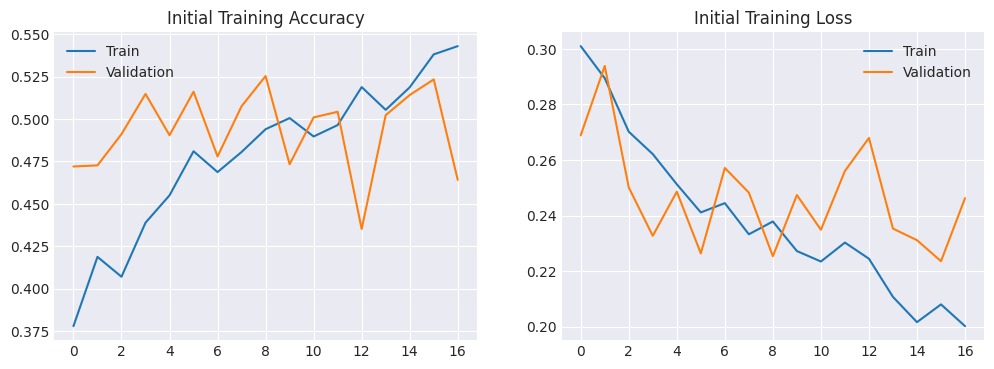


🔄 Preparing for fine-tuning...
🚀 Starting fine-tuning phase...
Epoch 1/10
292/292 [==============================] - ETA: 0s - loss: 0.2767 - accuracy: 0.4630 - precision: 0.8072 - recall: 0.1687
Epoch 1: val_accuracy improved from 0.52535 to 0.68598, saving model to best_mobilenetv2_model.h5
292/292 [==============================] - 106s 334ms/step - loss: 0.2767 - accuracy: 0.4630 - precision: 0.8072 - recall: 0.1687 - val_loss: 0.2038 - val_accuracy: 0.6860 - val_precision: 0.8388 - val_recall: 0.5688 - lr: 1.0000e-05
Epoch 2/10
290/292 [============================>.] - ETA: 0s - loss: 0.2654 - accuracy: 0.4605 - precision: 0.8191 - recall: 0.1726
Epoch 2: val_accuracy did not improve from 0.68598
292/292 [==============================] - 99s 338ms/step - loss: 0.2650 - accuracy: 0.4613 - precision: 0.8197 - recall: 0.1727 - val_loss: 0.2120 - val_accuracy: 0.6623 - val_precision: 0.8176 - val_recall: 0.5431 - lr: 1.0000e-05
Epoch 3/10
292/292 [==============================] - 

In [22]:
#==========================
#STEP 6: Model Training & Fine-Tuning (MobileNetV2)
#==========================

# Use callbacks defined in STEP 5
callbacks = [early_stop, reduce_lr, model_checkpoint]

# ------------------------
# 1️⃣ Initial training (frozen base)
# ------------------------
print("🚀 Starting initial training with frozen backbone...")
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    class_weight=class_weights_dict,
    callbacks=callbacks,
    verbose=1
)

# Plot initial training results
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Initial Training Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Initial Training Loss')
plt.legend()
plt.show()

# ------------------------
# 2️⃣ Fine-tuning phase
# ------------------------
print("\n🔄 Preparing for fine-tuning...")
base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False

# Recompile with same loss and metrics for consistency
model.compile(
    optimizer=optimizers.RMSprop(learning_rate=1e-5),
    loss=tfa.losses.SigmoidFocalCrossEntropy(alpha=0.25, gamma=2.0),
    metrics=['accuracy', 
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')]
)

print("🚀 Starting fine-tuning phase...")
history_finetune = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    class_weight=class_weights_dict,
    callbacks=callbacks,
    verbose=1
)

# Save final model
model.save('mobilenetv2_final.h5')
print("✅ Training complete! Model saved as mobilenetv2_final.h5")

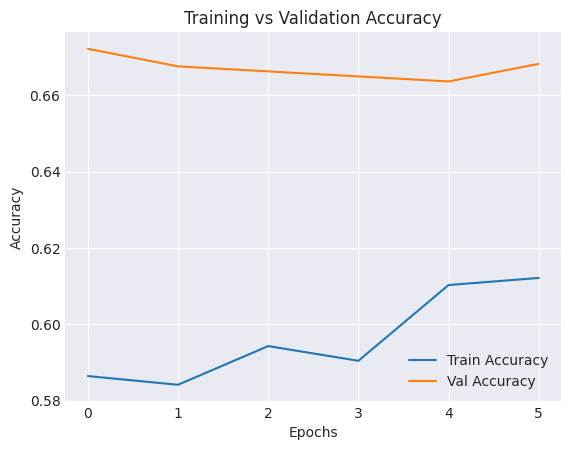

In [21]:
# Plot training history
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


2025-11-03 19:12:28.506933: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:442] Loaded cuDNN version 8907


47/47 [==============================] - 30s 509ms/step - loss: 0.8245 - accuracy: 0.7028
MobileNetV2 Test Accuracy: 0.7028
MobileNetV2 Test Loss: 0.8245
47/47 [==============================] - 12s 239ms/step
Classification Report:
              precision    recall  f1-score   support

       akiec       0.55      0.33      0.42        63
         bcc       0.46      0.57      0.51        68
         bkl       0.44      0.51      0.47       152
          df       0.03      0.14      0.06         7
         mel       0.38      0.55      0.45       187
          nv       0.91      0.80      0.85       996
        vasc       0.61      0.81      0.69        21

    accuracy                           0.70      1494
   macro avg       0.48      0.53      0.49      1494
weighted avg       0.75      0.70      0.72      1494



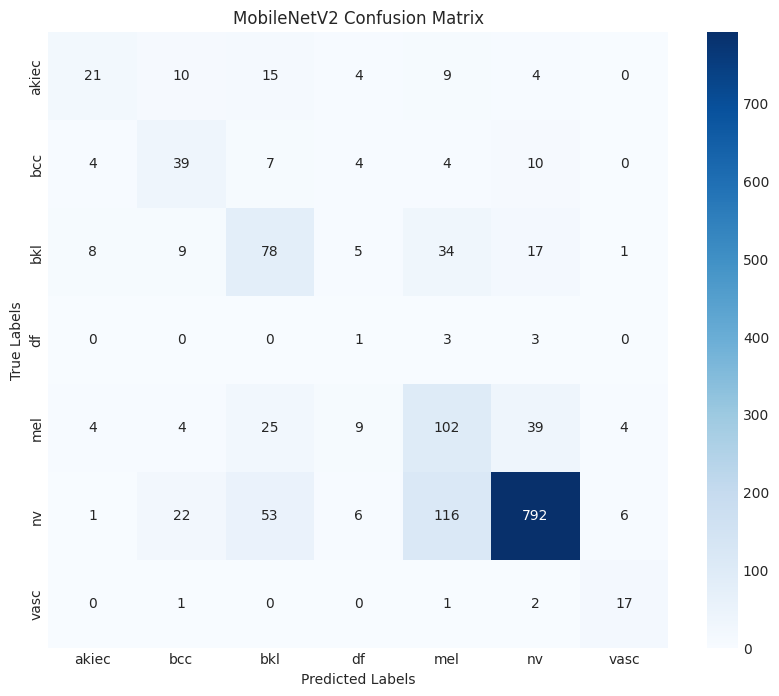

In [8]:
# ==========================
# STEP 7: Evaluation & Confusion Matrix (MobileNetV2)
# ==========================

from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1️⃣ Load the best MobileNetV2 model
best_mnv2_model = load_model("best_mobilenetv2_model.h5")

# 2️⃣ Evaluate on test set
test_loss, test_acc = best_mnv2_model.evaluate(test_generator)
print(f"MobileNetV2 Test Accuracy: {test_acc:.4f}")
print(f"MobileNetV2 Test Loss: {test_loss:.4f}")

# 3️⃣ Predict labels for test set
test_generator.reset()  # ensure predictions start from first batch
pred_probs = best_mnv2_model.predict(test_generator, verbose=1)
y_pred = np.argmax(pred_probs, axis=1)
y_true = test_generator.classes  # true labels

# 4️⃣ Classification report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=le.classes_, zero_division=0))

# 5️⃣ Confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.ylabel('True Labels')
plt.xlabel('Predicted Labels')
plt.title("MobileNetV2 Confusion Matrix")
plt.show()


In [8]:
# ==========================
# STEP 8 (Retry) – Fine-tuning MobileNetV2 properly
# ==========================

from tensorflow.keras.models import load_model
from tensorflow.keras import optimizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Ensure generators are loaded correctly
if 'train_generator' not in globals() or train_generator is None:
    print("❌ Generators missing — please rerun your data loading cell before this.")
else:
    # Load model if not in memory
    if 'model' not in globals():
        model = load_model("best_mobilenetv2_model.h5")
        print("✅ Loaded model from best_mobilenetv2_model.h5")

    # Compute class weights
    y_train = train_generator.classes
    classes = np.unique(y_train)
    cw = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
    class_weights_dict = {int(k): float(v) for k, v in zip(classes, cw)}
    print("✅ Computed class_weights_dict:", class_weights_dict)

    # Callbacks
    early_stop = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True, verbose=1)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1)
    checkpoint = ModelCheckpoint("best_mobilenetv2_finetuned.h5", monitor='val_accuracy', save_best_only=True, verbose=1)

    # Compile and train
    model.compile(optimizer=optimizers.RMSprop(learning_rate=5e-6),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    print("🚀 Starting fine-tuning (15 epochs, low LR)...")
    history_finetune = model.fit(
        train_generator,
        validation_data=val_generator,
        epochs=15,
        class_weight=class_weights_dict,
        callbacks=[early_stop, reduce_lr, checkpoint],
        verbose=1
    )

    print("✅ Fine-tuning complete! Best model saved as best_mobilenetv2_finetuned.h5")


✅ Loaded model from best_mobilenetv2_model.h5
✅ Computed class_weights_dict: {0: 4.832298136645963, 1: 2.625421822272216, 2: 1.3499132446500868, 3: 11.23916532905297, 4: 1.2990723562152133, 5: 0.21201477623690426, 6: 10.419642857142858}
🚀 Starting fine-tuning (15 epochs, low LR)...
Epoch 1/15


2025-11-02 22:46:20.484285: I tensorflow/compiler/xla/service/service.cc:168] XLA service 0x7eb2ea9a8400 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-11-02 22:46:20.484388: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce RTX 3050 Laptop GPU, Compute Capability 8.6
2025-11-02 22:46:20.507681: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-11-02 22:46:20.652925: I ./tensorflow/compiler/jit/device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


219/219 [==============================] - ETA: 0s - loss: 1.1455 - accuracy: 0.5944
Epoch 1: val_accuracy improved from -inf to 0.67149, saving model to best_mobilenetv2_finetuned.h5


/home/krish/skinvision-env/lib/python3.10/site-packages/keras/src/engine/training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


219/219 [==============================] - 110s 467ms/step - loss: 1.1455 - accuracy: 0.5944 - val_loss: 0.8646 - val_accuracy: 0.6715 - lr: 5.0000e-06
Epoch 2/15
219/219 [==============================] - ETA: 0s - loss: 1.1824 - accuracy: 0.5734
Epoch 2: val_accuracy did not improve from 0.67149
219/219 [==============================] - 99s 453ms/step - loss: 1.1824 - accuracy: 0.5734 - val_loss: 0.8722 - val_accuracy: 0.6629 - lr: 5.0000e-06
Epoch 3/15
219/219 [==============================] - ETA: 0s - loss: 1.1518 - accuracy: 0.5707
Epoch 3: val_accuracy did not improve from 0.67149
219/219 [==============================] - 101s 462ms/step - loss: 1.1518 - accuracy: 0.5707 - val_loss: 0.8853 - val_accuracy: 0.6590 - lr: 5.0000e-06
Epoch 4/15
219/219 [==============================] - ETA: 0s - loss: 1.1558 - accuracy: 0.5770
Epoch 4: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-06.

Epoch 4: val_accuracy did not improve from 0.67149
219/219 [==================

In [9]:
# ==========================
# STEP 9 – Deeper Fine-tuning of MobileNetV2
# ==========================
from tensorflow.keras.models import load_model
from tensorflow.keras import optimizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

model = load_model("best_mobilenetv2_finetuned.h5")
base_model = model.layers[0]  # MobilenetV2 base

# 🔓 Unfreeze deeper layers
for layer in base_model.layers[-80:]:
    layer.trainable = True

# ✅ Compile with slightly higher LR
model.compile(optimizer=optimizers.Adam(learning_rate=1e-5),
              loss='categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7, verbose=1)
checkpoint = ModelCheckpoint("best_mobilenetv2_deep_finetune.h5", monitor='val_accuracy', save_best_only=True, verbose=1)

print("🚀 Starting deeper fine-tuning (15 epochs, LR=1e-5)...")
history_deep = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    class_weight=class_weights_dict,
    callbacks=[early_stop, reduce_lr, checkpoint],
    verbose=1
)
print("✅ Deep fine-tuning complete! Best model saved as best_mobilenetv2_deep_finetune.h5")


🚀 Starting deeper fine-tuning (15 epochs, LR=1e-5)...
Epoch 1/15
219/219 [==============================] - ETA: 0s - loss: 1.5529 - accuracy: 0.5006
Epoch 1: val_accuracy improved from -inf to 0.67676, saving model to best_mobilenetv2_deep_finetune.h5
219/219 [==============================] - 112s 469ms/step - loss: 1.5529 - accuracy: 0.5006 - val_loss: 0.8638 - val_accuracy: 0.6768 - lr: 1.0000e-05
Epoch 2/15
219/219 [==============================] - ETA: 0s - loss: 1.3793 - accuracy: 0.4729
Epoch 2: val_accuracy did not improve from 0.67676
219/219 [==============================] - 107s 486ms/step - loss: 1.3793 - accuracy: 0.4729 - val_loss: 0.9354 - val_accuracy: 0.6504 - lr: 1.0000e-05
Epoch 3/15
219/219 [==============================] - ETA: 0s - loss: 1.3309 - accuracy: 0.4951
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.

Epoch 3: val_accuracy did not improve from 0.67676
219/219 [==============================] - 105s 478ms/step - loss: 1.330

In [1]:
from sklearn.utils import class_weight
import numpy as np

class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)
class_weights = dict(enumerate(class_weights))


NameError: name 'train_generator' is not defined

In [9]:
# ...existing code...
import os
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report

# 1) Check split DataFrames
for name in ('train_df','val_df','test_df'):
    if name in globals() and isinstance(globals()[name], pd.DataFrame):
        print(f"{name} OK: {len(globals()[name])} rows")
    else:
        print(f"{name} MISSING - rerun the split cell that creates it")

# 2) Overlap checks (if splits present)
if all(name in globals() and isinstance(globals()[name], pd.DataFrame) for name in ('train_df','val_df','test_df')):
    print("\nOverlap lesion_ids between splits:")
    print("train ∩ val:", len(set(train_df['lesion_id']).intersection(set(val_df['lesion_id']))))
    print("train ∩ test:", len(set(train_df['lesion_id']).intersection(set(test_df['lesion_id']))))
    print("val ∩ test:", len(set(val_df['lesion_id']).intersection(set(test_df['lesion_id']))))

# 3) Classification report: use existing preds if available, otherwise try to evaluate saved model
if 'y_true' in globals() and 'y_pred' in globals():
    print("\nUsing existing predictions:")
    print(classification_report(y_true, y_pred, target_names=le.classes_, zero_division=0))
else:
    try:
        from tensorflow.keras.models import load_model
        # Ensure test_generator exists
        if 'test_generator' not in globals():
            print("\ntest_generator missing - rerun the generator/data-loading cell")
        else:
            # prefer deepest fine-tuned model if present
            candidates = [
                "best_mobilenetv2_deep_finetune.h5",
                "best_mobilenetv2_finetuned.h5",
                "best_mobilenetv2_model.h5"
            ]
            model_path = next((p for p in candidates if os.path.exists(p)), None)
            if model_path is None:
                print("\nNo saved model (.h5) found in notebook working dir. Run training or place the model file here.")
            else:
                model = load_model(model_path)
                print(f"\nLoaded model: {model_path}")
                test_generator.reset()
                pred_probs = model.predict(test_generator, verbose=1)
                y_pred = np.argmax(pred_probs, axis=1)
                y_true = test_generator.classes
                print("\nClassification report:")
                print(classification_report(y_true, y_pred, target_names=le.classes_, zero_division=0))
    except Exception as e:
        print("Evaluation failed:", type(e).__name__, e)
# ...existing code...

train_df OK: 7002 rows
val_df OK: 1519 rows
test_df OK: 1494 rows

Overlap lesion_ids between splits:
train ∩ val: 0
train ∩ test: 0
val ∩ test: 0

Using existing predictions:
              precision    recall  f1-score   support

       akiec       0.55      0.33      0.42        63
         bcc       0.46      0.57      0.51        68
         bkl       0.44      0.51      0.47       152
          df       0.03      0.14      0.06         7
         mel       0.38      0.55      0.45       187
          nv       0.91      0.80      0.85       996
        vasc       0.61      0.81      0.69        21

    accuracy                           0.70      1494
   macro avg       0.48      0.53      0.49      1494
weighted avg       0.75      0.70      0.72      1494



In [10]:
# ...existing code...
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

# Oversample to median class size (use counts.max() if you prefer stronger balancing)
counts = train_df['dx'].value_counts()
target = int(counts.median())   # or counts.max()
rows = []
for cls, c in counts.items():
    cls_df = train_df[train_df['dx'] == cls]
    if c < target:
        reps = int(np.ceil(target / c))
        rows.append(pd.concat([cls_df] * reps, ignore_index=True))
    else:
        rows.append(cls_df)
train_df_bal = pd.concat(rows, ignore_index=True).sample(frac=1, random_state=SEED).reset_index(drop=True)

print("Balanced train counts:\n", train_df_bal['dx'].value_counts())

# Recreate train_generator using the balanced dataframe
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df_bal,
    x_col='image_path', y_col='dx',
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=True, seed=SEED
)

# Recompute class_weights_dict (optional if you still pass class_weight)
y_train_enc = le.fit_transform(train_df_bal['dx'])
cw = compute_class_weight('balanced', classes=np.unique(y_train_enc), y=y_train_enc)
class_weights_dict = dict(enumerate(cw))
print("Updated class_weights_dict:", class_weights_dict)
# ...existing code...

Balanced train counts:
 dx
nv       4718
mel       770
bkl       741
df        445
akiec     414
vasc      384
bcc       381
Name: count, dtype: int64
Found 7853 validated image filenames belonging to 7 classes.
Updated class_weights_dict: {0: 2.709799861973775, 1: 2.944506936632921, 2: 1.513977250819356, 3: 2.521027287319422, 4: 1.4569573283858999, 5: 0.23778235329740205, 6: 2.9215029761904763}


In [11]:
# ...existing code...
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras import optimizers
import numpy as np

# Callbacks
early_stop = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1)
checkpoint = ModelCheckpoint("best_mobilenetv2_balanced.h5", monitor='val_accuracy', save_best_only=True, verbose=1)

# 1) Compile with Adam + label smoothing for initial training (backbone frozen)
model.compile(
    optimizer='adam',
    loss=CategoricalCrossentropy(label_smoothing=0.05),
    metrics=['accuracy']
)

print("Starting initial training (frozen backbone)...")
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    class_weight=class_weights_dict,
    callbacks=[early_stop, reduce_lr, checkpoint],
    verbose=1
)

# 2) Unfreeze last 20 layers and fine-tune with low LR
base_model = model.layers[0]
base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),
    loss=CategoricalCrossentropy(label_smoothing=0.05),
    metrics=['accuracy']
)

print("Starting fine-tuning (unfrozen last 20 layers)...")
history_ft = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    class_weight=class_weights_dict,
    callbacks=[early_stop, reduce_lr, checkpoint],
    verbose=1
)
# ...existing code...

Starting initial training (frozen backbone)...
Epoch 1/10


2025-11-03 19:23:44.086396: I tensorflow/compiler/xla/service/service.cc:168] XLA service 0x7b005fa85100 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-11-03 19:23:44.086482: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce RTX 3050 Laptop GPU, Compute Capability 8.6
2025-11-03 19:23:44.113386: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-11-03 19:23:44.299023: I ./tensorflow/compiler/jit/device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


246/246 [==============================] - ETA: 0s - loss: 1.7157 - accuracy: 0.3922
Epoch 1: val_accuracy improved from -inf to 0.55036, saving model to best_mobilenetv2_balanced.h5
246/246 [==============================] - 204s 815ms/step - loss: 1.7157 - accuracy: 0.3922 - val_loss: 1.3707 - val_accuracy: 0.5504 - lr: 0.0010


/home/krish/skinvision-env/lib/python3.10/site-packages/keras/src/engine/training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Epoch 2/10
246/246 [==============================] - ETA: 0s - loss: 1.4635 - accuracy: 0.4731
Epoch 2: val_accuracy did not improve from 0.55036
246/246 [==============================] - 121s 493ms/step - loss: 1.4635 - accuracy: 0.4731 - val_loss: 1.5600 - val_accuracy: 0.4049 - lr: 0.0010
Epoch 3/10
246/246 [==============================] - ETA: 0s - loss: 1.3926 - accuracy: 0.5041
Epoch 3: val_accuracy did not improve from 0.55036
246/246 [==============================] - 119s 481ms/step - loss: 1.3926 - accuracy: 0.5041 - val_loss: 1.4105 - val_accuracy: 0.4674 - lr: 0.0010
Epoch 4/10
246/246 [==============================] - ETA: 0s - loss: 1.3674 - accuracy: 0.5003
Epoch 4: val_accuracy did not improve from 0.55036
246/246 [==============================] - 120s 486ms/step - loss: 1.3674 - accuracy: 0.5003 - val_loss: 1.3376 - val_accuracy: 0.4970 - lr: 0.0010
Epoch 5/10
246/246 [==============================] - ETA: 0s - loss: 1.3274 - accuracy: 0.5221
Epoch 5: val_accura